<h1 style="text-align:center">MRI-Based Brain Tumor Classification 
Using Transfer Learning with Explainable 
AI and Automated Diagnostic Reporting</h1>

## Setup and Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

## Reproducibility (Random Seed)

In [19]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

## Project & Dataset Path

In [20]:
PROJECT_ROOT = Path().resolve().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw"

classes = [
    "glioma",
    "meningioma",
    "pituitary",
    "no_tumor"
]

print("Project Root:", PROJECT_ROOT)
print("Dataset Path:", DATASET_PATH)

Project Root: C:\Users\itxab\Downloads\AI\Brain_Tumor_Detection_Using_Deep_Learning
Dataset Path: C:\Users\itxab\Downloads\AI\Brain_Tumor_Detection_Using_Deep_Learning\data\raw


## Build Dataset Manifest

In [25]:
import os
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
DATASET_PATH = PROJECT_ROOT / "data" / "raw"

classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

data = []

for label in classes:
    folder = DATASET_PATH / label

    for img_name in os.listdir(folder):
        img_path = folder / img_name
        data.append([str(img_path), label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print(df.head())
print("\nClass Distribution:")
print(df["label"].value_counts())

                                          image_path   label
0  C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...  glioma
1  C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...  glioma
2  C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...  glioma
3  C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...  glioma
4  C:\Users\itxab\Downloads\AI\Brain_Tumor_Detect...  glioma

Class Distribution:
label
no_tumor      1595
pituitary     1457
meningioma    1339
glioma        1321
Name: count, dtype: int64


## Save Dataset Manifest

In [26]:
manifest_path = PROJECT_ROOT / "data" / "dataset_manifest.csv"

df.to_csv(manifest_path, index=False)

print("Manifest Saved:", manifest_path)

Manifest Saved: C:\Users\itxab\Downloads\AI\Brain_Tumor_Detection_Using_Deep_Learning\data\dataset_manifest.csv


## Class Distribution Visualization

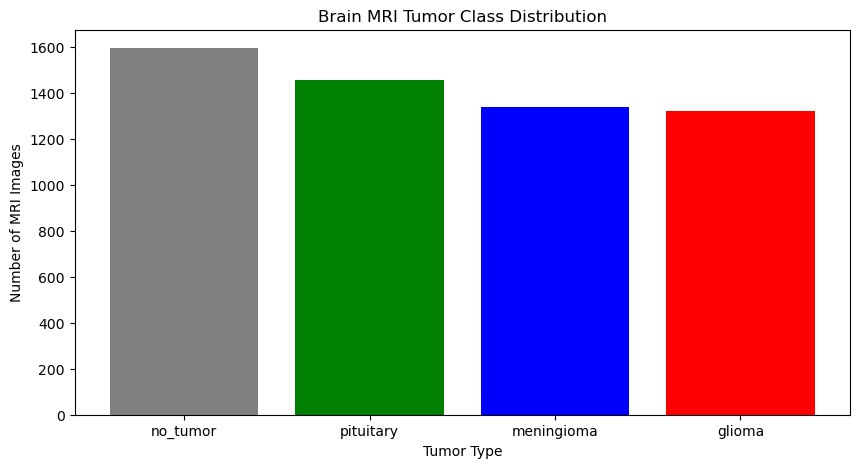

In [27]:
class_colors = {
    "glioma": "red",
    "meningioma": "blue",
    "pituitary": "green",
    "no_tumor": "gray"
}

counts = df["label"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    counts.index,
    counts.values,
    color=[class_colors[x] for x in counts.index]
)

plt.title("Brain MRI Tumor Class Distribution")

plt.xlabel("Tumor Type")
plt.ylabel("Number of MRI Images")

plt.xticks(rotation=0)

plt.show()

## Random MRI Sample Visualization

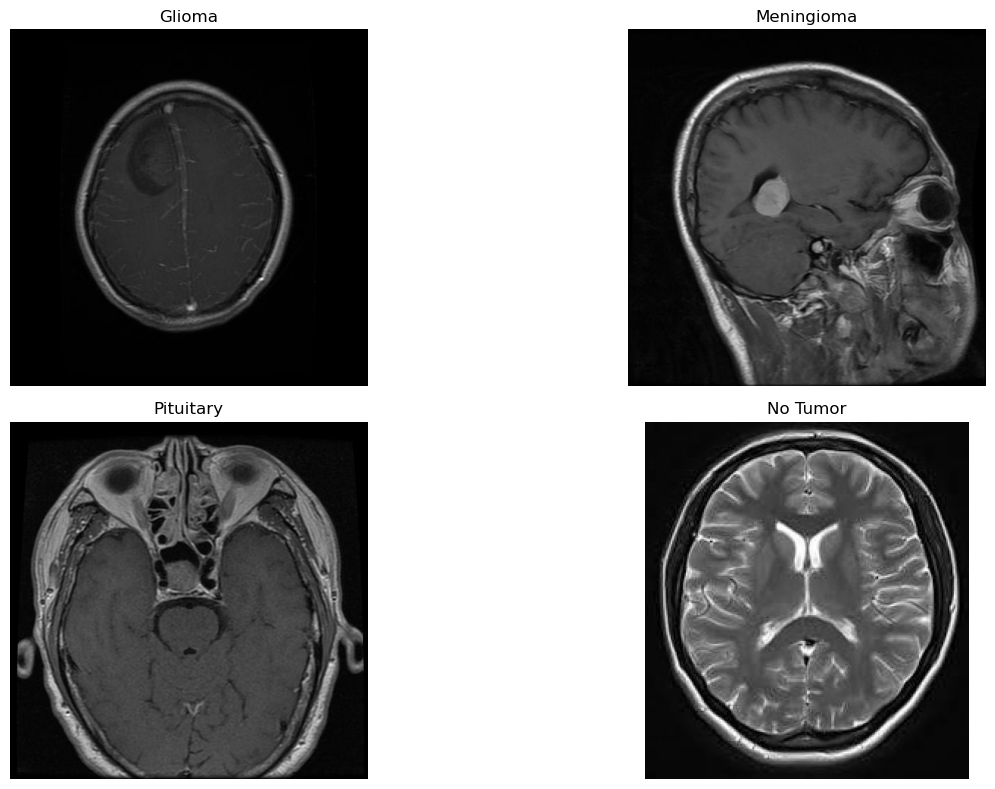

In [30]:
plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    class_images = df[df["label"] == cls]["image_path"].values
    img_path = random.choice(class_images)
    img = Image.open(img_path)
    plt.subplot(2,2,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{cls.replace('_', ' ').title()}")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Multiple MRI Samples Per Class

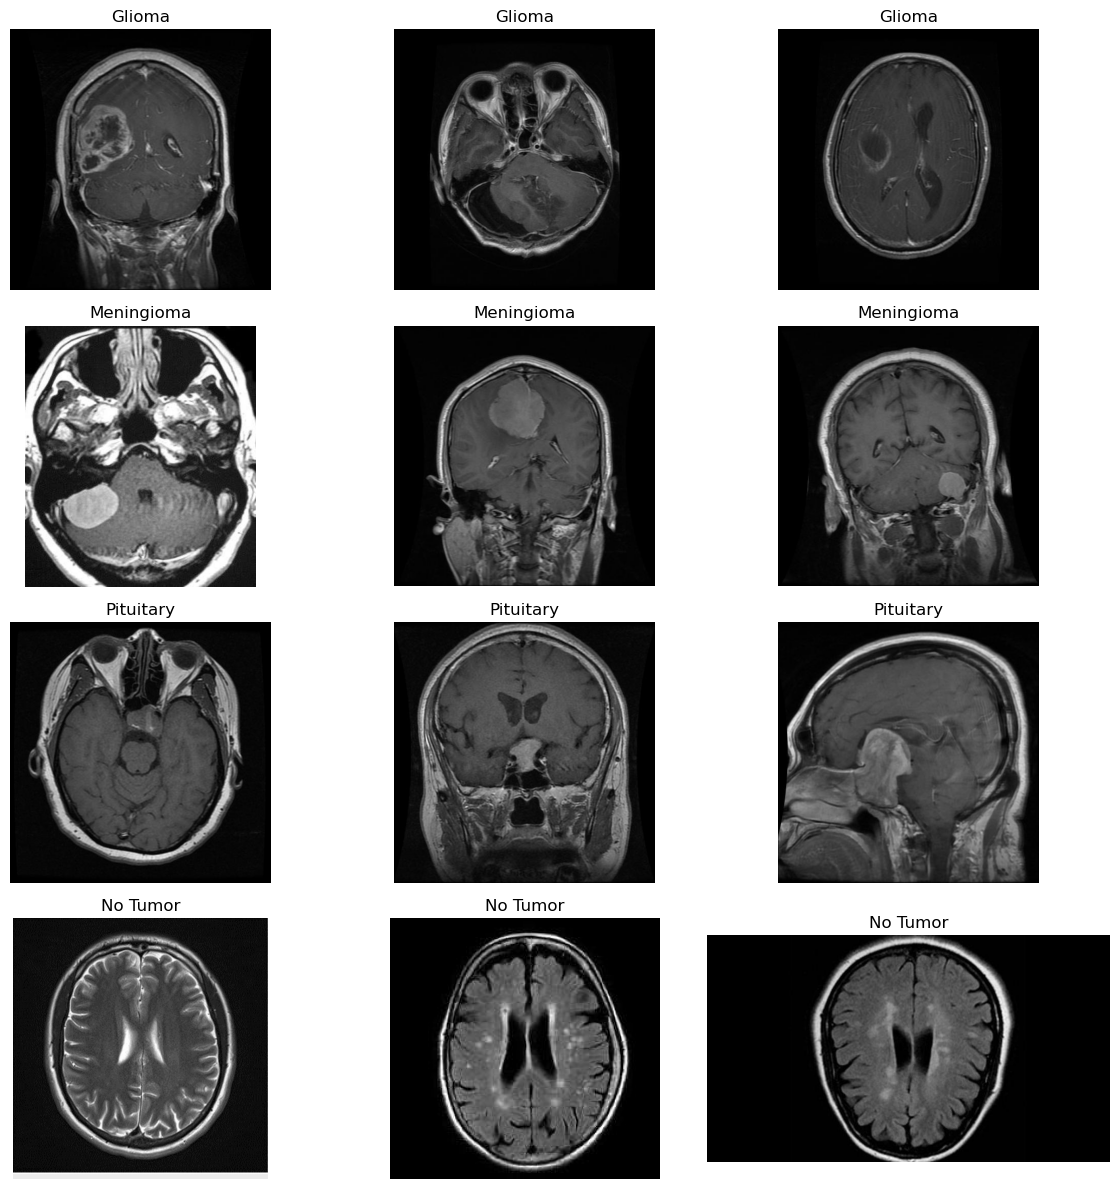

In [31]:
fig, axes = plt.subplots(len(classes), 3, figsize=(12,12))

for i, cls in enumerate(classes):

    class_folder = DATASET_PATH / cls
    images = os.listdir(class_folder)
    sample_images = random.sample(images, 3)
    
    for j, img_name in enumerate(sample_images):
        img_path = class_folder / img_name
        img = Image.open(img_path)
        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")
        axes[i, j].set_title(f"{cls.replace('_', ' ').title()}")

plt.tight_layout()
plt.show()

## Corrupted Image Detection

In [32]:
corrupted = []

for path in df["image_path"]:

    try:
        img = Image.open(path)
        img.verify()

    except:
        corrupted.append(path)

print("Corrupted Images:", len(corrupted))

Corrupted Images: 14


In [33]:
df_clean = df[
    ~df["image_path"].isin(corrupted)
].reset_index(drop=True)

print("Original Dataset Size:", len(df))
print("Cleaned Dataset Size:", len(df_clean))

df = df_clean

Original Dataset Size: 5712
Cleaned Dataset Size: 5698


In [10]:
corrupt_df = pd.DataFrame(corrupted, columns=["corrupted_image_path"])
corrupt_df.to_csv(PROJECT_ROOT / "reports" / "corrupted_images.csv", index=False)

## Save Corrupted Image Report

In [34]:
corrupt_df = pd.DataFrame(
    corrupted,
    columns=["corrupted_image_path"]
)

corrupt_df.to_csv(
    PROJECT_ROOT / "reports" / "corrupted_images.csv",
    index=False
)

print("Corrupted image report saved.")

Corrupted image report saved.


## Duplicate Image Detection

In [36]:
hashes = {}

duplicates = []

for path in df["image_path"]:

    with open(path, "rb") as f:
        filehash = hashlib.md5(f.read()).hexdigest()

    if filehash in hashes:
        duplicates.append(path)
    else:
        hashes[filehash] = path

print("Duplicate Images:", len(duplicates))

Duplicate Images: 207


## Remove Duplicate Images

In [37]:
df = df[
    ~df["image_path"].isin(duplicates)
].reset_index(drop=True)

print(
    "Dataset Size After Duplicate Removal:",
    len(df)
)

Dataset Size After Duplicate Removal: 5491


## Image Shape / Resolution Analysis

In [38]:
shapes = []

for path in df["image_path"].sample(200):

    img = Image.open(path)

    shapes.append(
        np.array(img).shape
    )

print(set(shapes))

{(168, 300, 3), (444, 468, 3), (248, 257, 3), (213, 236, 3), (251, 447, 3), (624, 491, 3), (401, 312, 3), (442, 400, 3), (259, 225, 3), (234, 210, 3), (225, 225, 3), (512, 512), (350, 350, 3), (417, 428, 3), (259, 194, 3), (252, 200, 3), (630, 630, 3), (449, 359, 3), (236, 236, 3), (201, 173, 3), (244, 206, 3), (242, 208, 3), (501, 456, 3), (512, 512, 3), (248, 203, 3), (217, 232, 3), (345, 300, 3), (664, 550, 3), (198, 150, 3), (361, 642, 3), (183, 275, 3), (396, 411, 3), (251, 201, 3), (234, 215, 3), (192, 192, 3), (240, 210, 3), (380, 336, 3), (221, 228, 3)}


## Image Width & Height Distribution

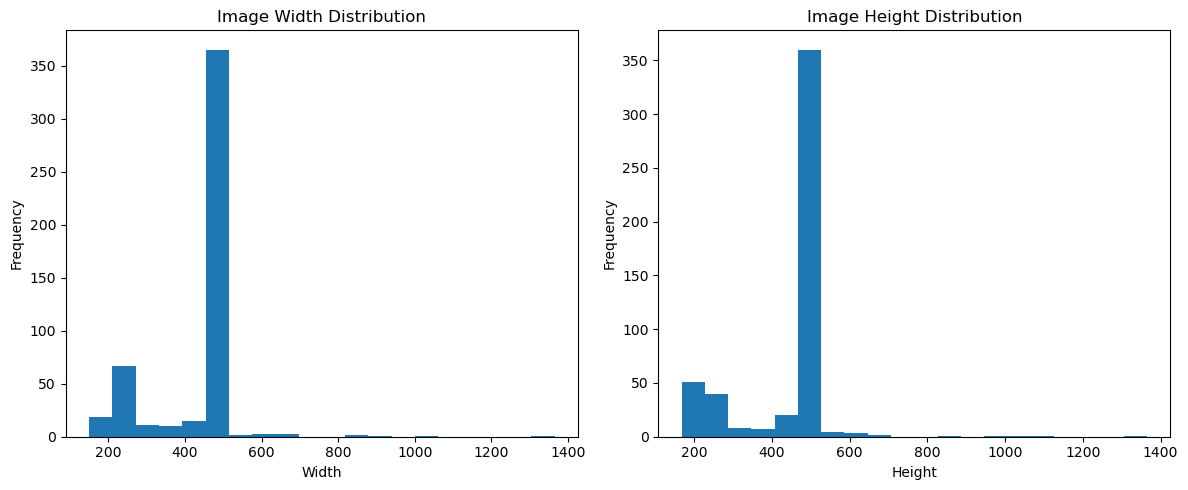

In [39]:
widths = []
heights = []

for path in df["image_path"].sample(500):

    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.hist(widths, bins=20)

plt.title("Image Width Distribution")

plt.xlabel("Width")
plt.ylabel("Frequency")

plt.subplot(1,2,2)

plt.hist(heights, bins=20)

plt.title("Image Height Distribution")

plt.xlabel("Height")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## RGB vs Grayscale Validation

In [40]:
modes = []

for path in df["image_path"].sample(200):

    img = Image.open(path)

    modes.append(img.mode)

print(
    pd.Series(modes).value_counts()
)

RGB    165
L       35
Name: count, dtype: int64


## Pixel Intensity Distribution

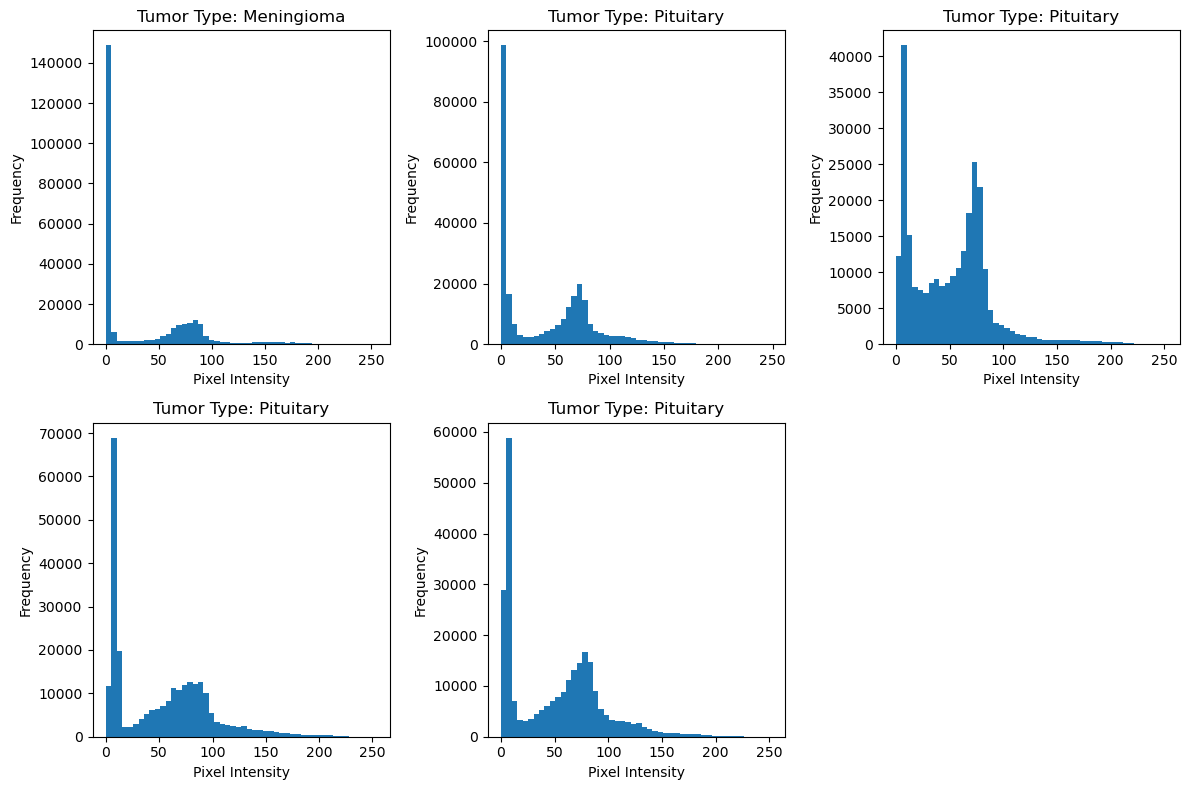

In [41]:
sample_df = df.sample(5)

plt.figure(figsize=(12,8))

for i, row in enumerate(sample_df.itertuples()):

    img = Image.open(
        row.image_path
    ).convert("L")

    arr = np.array(img)

    plt.subplot(2,3,i+1)

    plt.hist(arr.ravel(), bins=50)

    plt.title(
        f"Tumor Type: {row.label.replace('_', ' ').title()}"
    )

    plt.xlabel("Pixel Intensity")

    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Class-wise Mean MRI Images

In [42]:
def mean_image(class_name):

    imgs = df[
        df["label"] == class_name
    ]["image_path"].sample(50)

    acc = None

    for p in imgs:

        img = cv2.imread(p, 0)

        img = cv2.resize(
            img,
            (224,224)
        )

        if acc is None:

            acc = img.astype(np.float32)

        else:

            acc += img

    acc /= len(imgs)

    return acc

## Visualize Mean Images

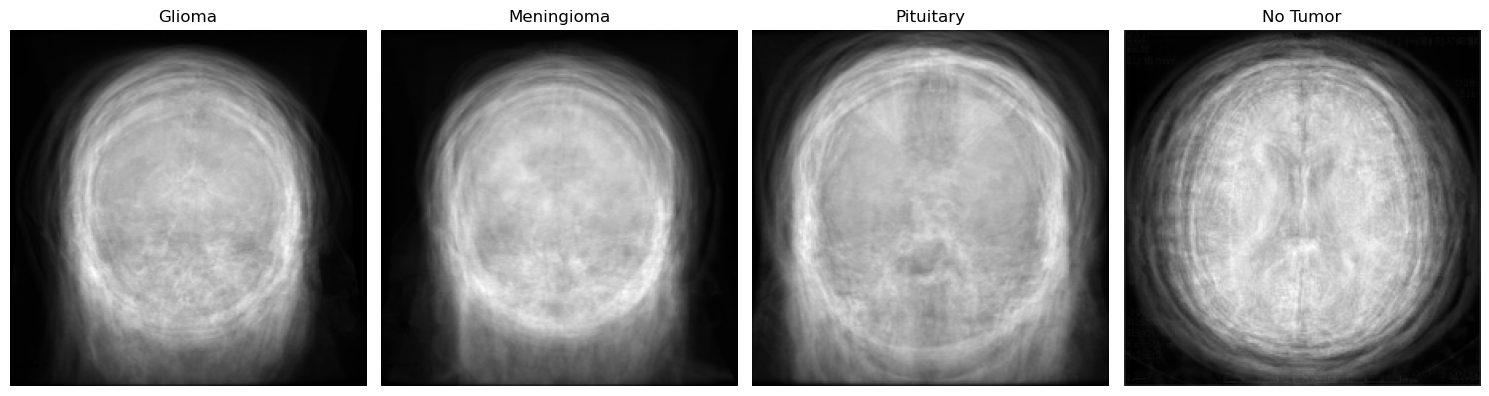

In [43]:
plt.figure(figsize=(15,5))

for i, c in enumerate(classes):

    plt.subplot(
        1,
        len(classes),
        i+1
    )

    plt.imshow(
        mean_image(c),
        cmap="gray"
    )

    plt.title(
        f"{c.replace('_', ' ').title()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Brightness / Intensity Statistics

In [44]:
def brightness(path):

    img = Image.open(path).convert("L")

    return np.array(img).mean()

df["brightness"] = df["image_path"].apply(brightness)

df.groupby("label")["brightness"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
glioma,1321.0,32.803638,8.583266,13.748398,26.088947,31.649597,38.722229,68.510426
meningioma,1333.0,43.432917,14.193745,18.292336,34.978962,40.840332,46.770496,137.769070
no_tumor,1404.0,61.235301,21.400439,9.777208,46.230555,57.298271,75.226198,125.152009
pituitary,1433.0,49.174813,8.228820,24.695900,43.937294,49.667728,54.188229,102.333716


## Brightness Distribution Per Tumor Type

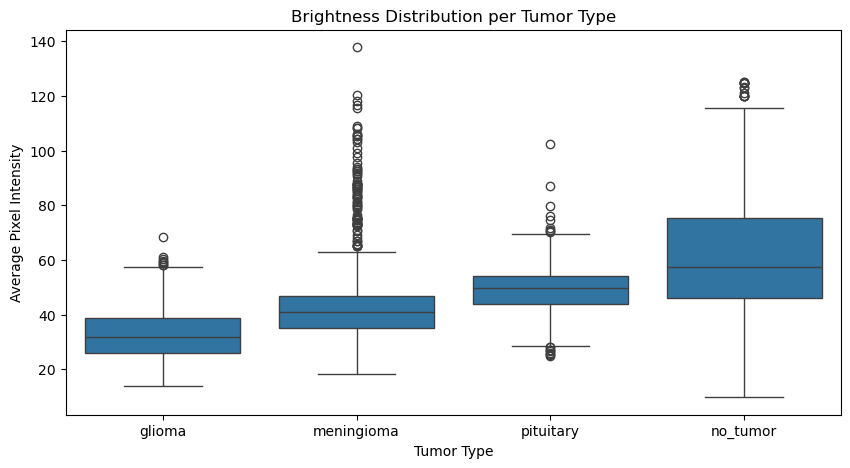

In [45]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="label",
    y="brightness"
)

plt.title(
    "Brightness Distribution per Tumor Type"
)

plt.xlabel("Tumor Type")

plt.ylabel("Average Pixel Intensity")

plt.show()

## Edge Detection Analysis

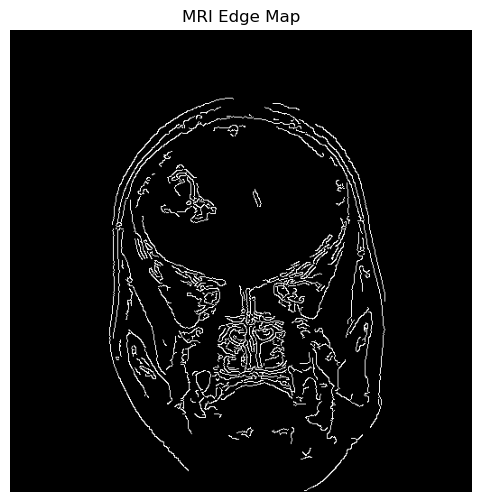

In [46]:
sample_path = df.iloc[0]["image_path"]

img = cv2.imread(sample_path, 0)

edges = cv2.Canny(
    img,
    100,
    200
)

plt.figure(figsize=(6,6))

plt.imshow(edges, cmap="gray")

plt.title("MRI Edge Map")

plt.axis("off")

plt.show()

## Save Cleaned Dataset Manifest

In [47]:
df.to_csv(
    PROJECT_ROOT / "data" / "clean_dataset_manifest.csv",
    index=False
)

print("Cleaned manifest saved.")

Cleaned manifest saved.
